# Big Data EDA

In [217]:
import os
import sys

root_dir = os.path.abspath("..")

if root_dir not in sys.path:
    sys.path.append(root_dir)

In [218]:
from database.db_config import db_connect
import numpy as np
import pandas as pd

conn = db_connect()
df = pd.read_sql_query("SELECT * FROM customers", conn, index_col="customer_id")
df.head()

Database connected successfully


C:\Users\Ashish\AppData\Local\Temp\ipykernel_27364\1254177186.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT * FROM customers", conn, index_col="customer_id")


,tenure,monthly_charges,contract,tech_support,churn
customer_id,,,,,
CUST-0000,52.0,110.0,Two year,Yes,No
CUST-0001,15.0,120.0,Month-to-month,Yes,Yes
CUST-0002,72.0,85.0,Two year,No,No
CUST-0003,61.0,120.0,Month-to-month,Yes,Yes
CUST-0004,21.0,95.0,Month-to-month,No,Yes


In [219]:
df.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, CUST-0000 to CUST-9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure           9500 non-null   float64
 1   monthly_charges  9500 non-null   float64
 2   contract         10000 non-null  str    
 3   tech_support     10000 non-null  str    
 4   churn            10000 non-null  str    
dtypes: float64(2), str(3)
memory usage: 468.8+ KB


In [220]:
df.describe()

,tenure,monthly_charges
count,9500.000000,9500.000000
mean,36.452737,102.340000
std,20.767888,13.104453
min,1.000000,85.000000
25%,18.000000,90.000000
50%,36.000000,95.000000
75%,55.000000,115.000000
max,72.000000,120.000000


In [221]:
df.isna().sum()

tenure             500
monthly_charges    500
contract             0
tech_support         0
churn                0
dtype: int64

In [222]:
from sklearn.impute import SimpleImputer

simple_imputer = SimpleImputer()
imputed_cols = simple_imputer.fit_transform(df[["tenure", "monthly_charges"]])
df[["tenure", "monthly_charges"]] = imputed_cols
df.isna().sum()

tenure             0
monthly_charges    0
contract           0
tech_support       0
churn              0
dtype: int64

In [223]:
df.head()

,tenure,monthly_charges,contract,tech_support,churn
customer_id,,,,,
CUST-0000,52.0,110.0,Two year,Yes,No
CUST-0001,15.0,120.0,Month-to-month,Yes,Yes
CUST-0002,72.0,85.0,Two year,No,No
CUST-0003,61.0,120.0,Month-to-month,Yes,Yes
CUST-0004,21.0,95.0,Month-to-month,No,Yes


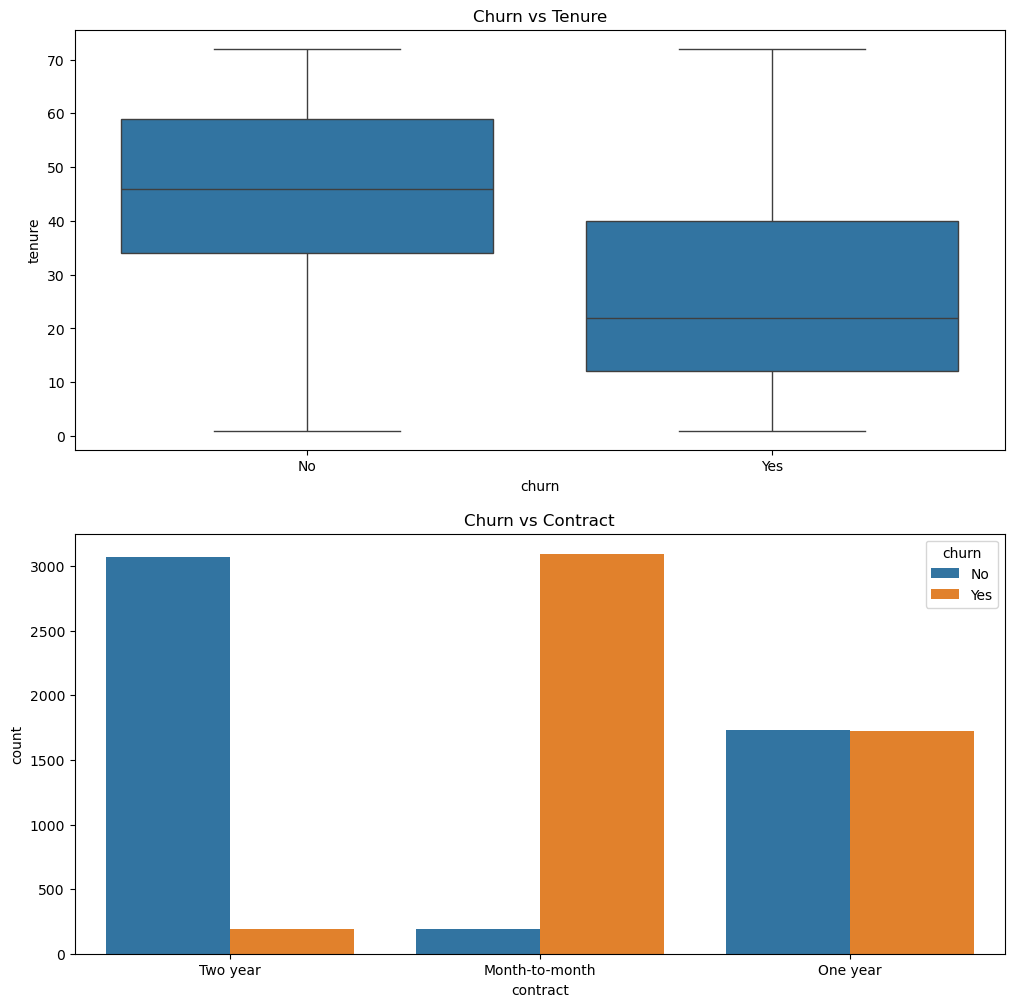

In [224]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,12))

plt.subplot(2,1,1)
sns.boxplot(x="churn", y="tenure", data=df)
plt.title("Churn vs Tenure")

plt.subplot(2,1,2)
sns.countplot(x="contract", hue="churn", data=df)
plt.title("Churn vs Contract")


plt.show()

In [225]:
bin_map = {"Yes" : 1, "No" : 0}
df["churn"] = df["churn"].map(bin_map)
df["tech_support"] = df["tech_support"].map(bin_map)
df.head()

,tenure,monthly_charges,contract,tech_support,churn
customer_id,,,,,
CUST-0000,52.0,110.0,Two year,1,0
CUST-0001,15.0,120.0,Month-to-month,1,1
CUST-0002,72.0,85.0,Two year,0,0
CUST-0003,61.0,120.0,Month-to-month,1,1
CUST-0004,21.0,95.0,Month-to-month,0,1


In [226]:
from sklearn.preprocessing import OneHotEncoder

one_hot = OneHotEncoder(sparse_output=False)
cat_cols = df.select_dtypes(include=[str]).columns
encoded_data = one_hot.fit_transform(df[cat_cols])
df_cat_encoded = pd.DataFrame(encoded_data, 
                              columns=one_hot.get_feature_names_out(cat_cols), 
                              index=df.index)

In [227]:
df_cat_encoded.head()

,contract_Month-to-month,contract_One year,contract_Two year
customer_id,,,
CUST-0000,0.0,0.0,1.0
CUST-0001,1.0,0.0,0.0
CUST-0002,0.0,0.0,1.0
CUST-0003,1.0,0.0,0.0
CUST-0004,1.0,0.0,0.0


In [228]:
df = pd.concat([df.drop(columns=cat_cols), df_cat_encoded], axis=1)
df.head()

,tenure,monthly_charges,tech_support,churn,contract_Month-to-month,contract_One year,contract_Two year
customer_id,,,,,,,
CUST-0000,52.0,110.0,1,0,0.0,0.0,1.0
CUST-0001,15.0,120.0,1,1,1.0,0.0,0.0
CUST-0002,72.0,85.0,0,0,0.0,0.0,1.0
CUST-0003,61.0,120.0,1,1,1.0,0.0,0.0
CUST-0004,21.0,95.0,0,1,1.0,0.0,0.0


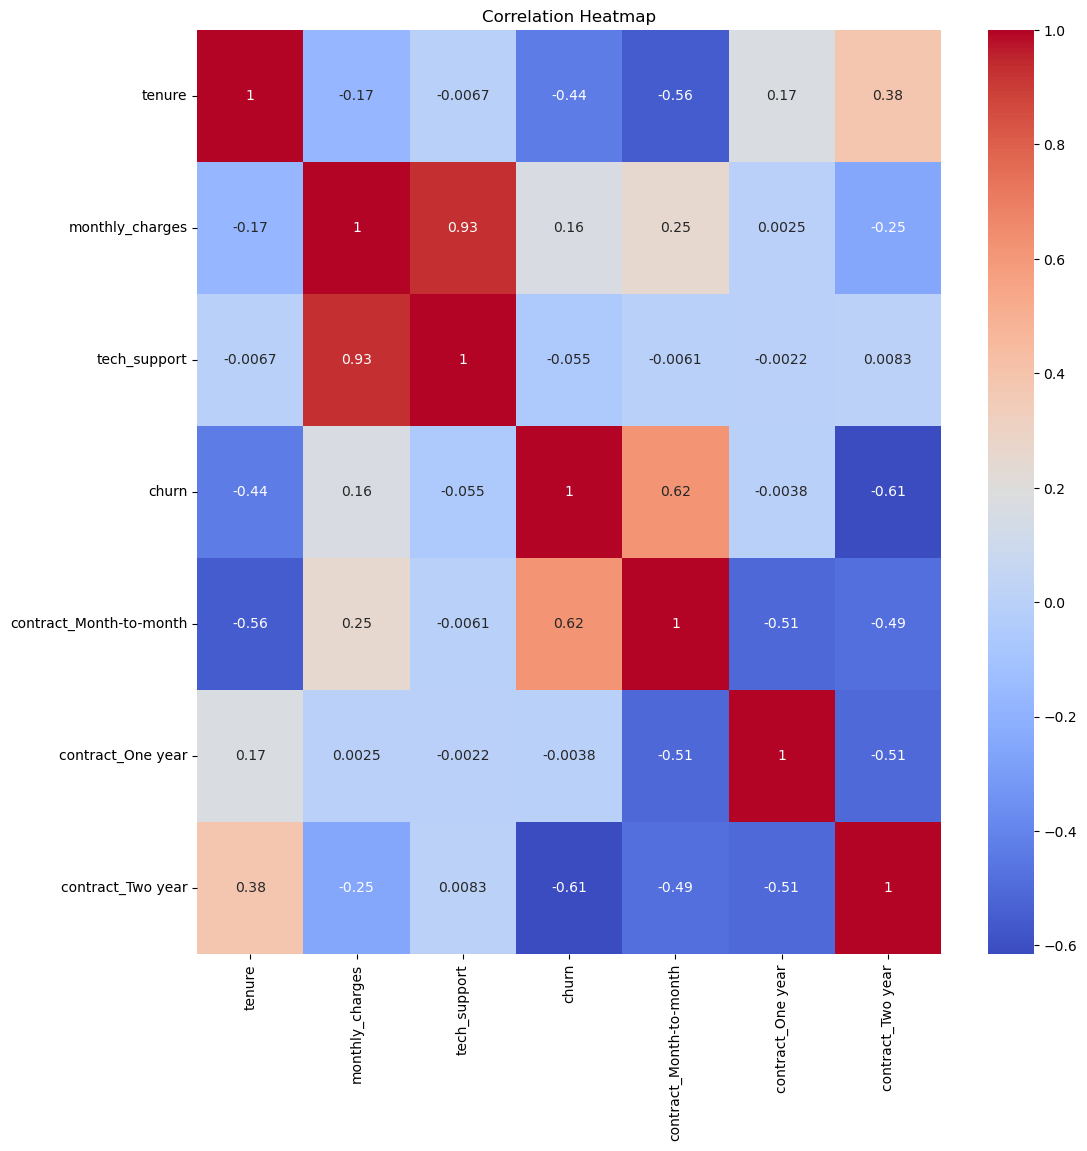

In [229]:
corr_matrix = df.corr()

plt.figure(figsize=(12,12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [230]:
df.head()

,tenure,monthly_charges,tech_support,churn,contract_Month-to-month,contract_One year,contract_Two year
customer_id,,,,,,,
CUST-0000,52.0,110.0,1,0,0.0,0.0,1.0
CUST-0001,15.0,120.0,1,1,1.0,0.0,0.0
CUST-0002,72.0,85.0,0,0,0.0,0.0,1.0
CUST-0003,61.0,120.0,1,1,1.0,0.0,0.0
CUST-0004,21.0,95.0,0,1,1.0,0.0,0.0


In [231]:
mm_cat = df["contract_Month-to-month"].copy()
mm_cat

customer_id
CUST-0000    0.0
CUST-0001    1.0
CUST-0002    0.0
CUST-0003    1.0
CUST-0004    1.0
            ... 
CUST-9995    0.0
CUST-9996    0.0
CUST-9997    0.0
CUST-9998    0.0
CUST-9999    1.0
Name: contract_Month-to-month, Length: 10000, dtype: float64

In [232]:
from sklearn.model_selection import StratifiedShuffleSplit

strata_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_i, test_i in strata_split.split(df, mm_cat):
    df_train = df.iloc[train_i].copy()
    df_test = df.iloc[test_i].copy()
    
print(df_train.info(), df_test.info())

<class 'pandas.DataFrame'>
Index: 8000 entries, CUST-8277 to CUST-6314
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tenure                   8000 non-null   float64
 1   monthly_charges          8000 non-null   float64
 2   tech_support             8000 non-null   int64  
 3   churn                    8000 non-null   int64  
 4   contract_Month-to-month  8000 non-null   float64
 5   contract_One year        8000 non-null   float64
 6   contract_Two year        8000 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 500.0+ KB
<class 'pandas.DataFrame'>
Index: 2000 entries, CUST-3710 to CUST-8903
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tenure                   2000 non-null   float64
 1   monthly_charges          2000 non-null   float64
 2   tech_support             2000 non-

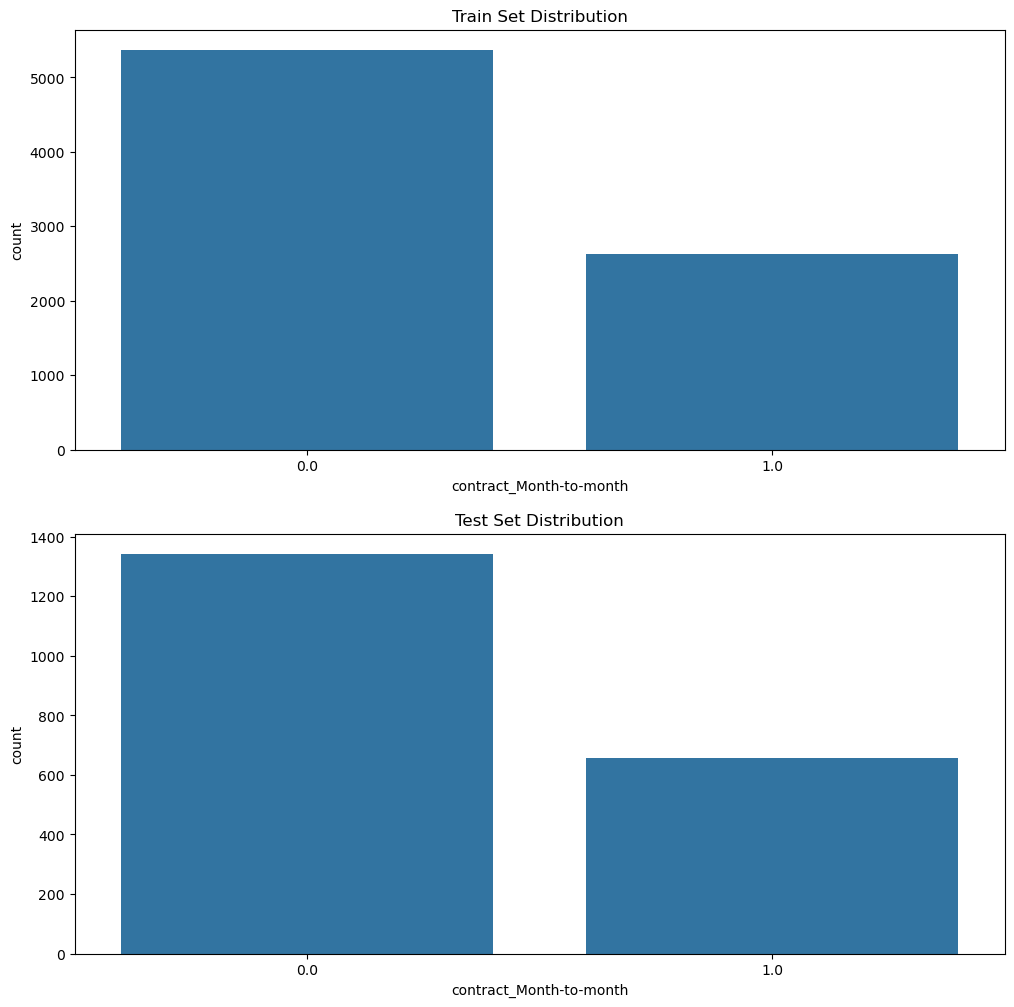

In [233]:
plt.figure(figsize=(12,12))

plt.subplot(2,1,1)
sns.countplot(x="contract_Month-to-month", data=df_train)
plt.title("Train Set Distribution")

plt.subplot(2,1,2)
sns.countplot(x="contract_Month-to-month", data=df_test)
plt.title("Test Set Distribution")

plt.show()

In [234]:
y_train = df_train["churn"].copy()
y_test = df_test["churn"].copy()
x_train = df_train.drop(columns=["churn"]).copy()
x_test = df_test.drop(columns=["churn"]).copy()
print(y_train.info(), y_test.info())

<class 'pandas.Series'>
Index: 8000 entries, CUST-8277 to CUST-6314
Series name: churn
Non-Null Count  Dtype
--------------  -----
8000 non-null   int64
dtypes: int64(1)
memory usage: 383.0+ KB
<class 'pandas.Series'>
Index: 2000 entries, CUST-3710 to CUST-8903
Series name: churn
Non-Null Count  Dtype
--------------  -----
2000 non-null   int64
dtypes: int64(1)
memory usage: 95.8+ KB
None None


In [235]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

x_val_nn, x_train_nn, y_val_nn, y_train_nn = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)
scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_train_nn_scaled = scaler.fit_transform(x_train_nn)
x_val_nn_scaled = scaler.transform(x_val_nn)
x_test_scaled = scaler.transform(x_test)


In [236]:
print(x_train_scaled,x_train_nn_scaled, x_val_nn_scaled,x_test_scaled)

[[0.90140845 0.14285714 0.         0.         1.         0.        ]
 [0.33802817 0.85714286 1.         0.         1.         0.        ]
 [0.18309859 1.         1.         1.         0.         0.        ]
 ...
 [0.36619718 0.85714286 1.         0.         1.         0.        ]
 [0.         1.         1.         1.         0.         0.        ]
 [0.53521127 0.71428571 1.         0.         0.         1.        ]] [[0.71830986 0.85714286 1.         0.         1.         0.        ]
 [0.49295775 0.         0.         0.         0.         1.        ]
 [0.49933432 0.71428571 1.         0.         0.         1.        ]
 ...
 [0.22535211 0.14285714 0.         0.         1.         0.        ]
 [0.08450704 0.28571429 0.         1.         0.         0.        ]
 [0.23943662 1.         1.         1.         0.         0.        ]] [[0.28169014 0.85714286 1.         0.         1.         0.        ]
 [0.49933432 0.         0.         0.         0.         1.        ]
 [0.87323944 0.1428571

In [237]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train_scaled, y_train)

rand_for = RandomForestClassifier(oob_score=True, random_state=42)
rand_for.fit(x_train_scaled, y_train)

dec_tree = DecisionTreeClassifier()
dec_tree.fit(x_train_scaled, y_train)

# Initial Predictions(To be Discared)
log_reg_pred = log_reg.predict(x_train_scaled)
rand_for_pred = rand_for.predict(x_train_scaled)
dec_tree_pred = dec_tree.predict(x_train_scaled)

# Accuracy
log_reg_e = cross_val_score(
    log_reg,
    x_train_scaled,
    y_train,
    scoring="accuracy",
    cv=10
)
rand_for_e = cross_val_score(
    rand_for,
    x_train_scaled,
    y_train,
    scoring="accuracy",
    cv=10
)
dec_tree_e = cross_val_score(
    dec_tree,
    x_train_scaled,
    y_train,
    scoring="accuracy",
    cv=10
)

In [238]:
print("Logistic Reg", log_reg_e)
print("Random Forest", rand_for_e)
print("Decision Tree", dec_tree_e)

Logistic Reg [0.82875 0.8125  0.82625 0.77875 0.7925  0.79625 0.78    0.81125 0.8
 0.80375]
Random Forest [0.81125 0.79625 0.83625 0.79875 0.79    0.78    0.79875 0.7925  0.77375
 0.80375]
Decision Tree [0.81    0.78625 0.835   0.795   0.79    0.77    0.8     0.79375 0.785
 0.79625]


In [239]:
print("Logistic Reg :", log_reg_e.mean())
print("Random Forest :", rand_for_e.mean())
print("Decision Tree :", dec_tree_e.mean())

Logistic Reg : 0.8029999999999999
Random Forest : 0.798125
Decision Tree : 0.796125


In [240]:
from sklearn.model_selection import GridSearchCV

dec_tree_grid = {
    'max_depth' : [None, 10, 20, 30]
}

rand_for_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [None, 10, 20, 30],
    'min_samples_split' : [2, 5, 10]
}

dec_tree_grid_search = GridSearchCV(
    estimator=dec_tree,
    param_grid=dec_tree_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

rand_for_grid_search = GridSearchCV(
    estimator=rand_for,
    param_grid=rand_for_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

In [241]:
dec_tree_grid_search.fit(x_train_scaled, y_train)
rand_for_grid_search.fit(x_train_scaled, y_train)
print(f"For Decision Tree : {dec_tree_grid_search.best_score_} and {dec_tree_grid_search.best_params_}")
print(f"For Random Forest : {rand_for_grid_search.best_score_} and {rand_for_grid_search.best_params_}")

For Decision Tree : 0.79925 and {'max_depth': 10}
For Random Forest : 0.80625 and {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


In [242]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    param_grid_lr = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],  
        'penalty': ['l1', 'l2'],              
        'solver': ['liblinear', 'saga']       
    }

    grid_search_lr = GridSearchCV(
        estimator=log_reg, 
        param_grid=param_grid_lr, 
        cv=5, 
        scoring='accuracy'
        )
    grid_search_lr.fit(x_train_scaled, y_train)

    print(f"For Logistic Reggression : {grid_search_lr.best_score_} and {grid_search_lr.best_params_}")

For Logistic Reggression : 0.803125 and {'C': 100, 'penalty': 'l1', 'solver': 'saga'}


In [243]:
# Best Random Forest Model
best_rf_model = rand_for_grid_search.best_estimator_

# Best Logistic Regression Model
best_lr_model = grid_search_lr.best_estimator_

In [244]:
import tensorflow as tf

model = tf.keras.Sequential([
    
    # Input Shape
    tf.keras.Input(shape=(6,)),
    
    # Hidden Layer 1
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    
    # Hidden Layer 2
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    
    # Output Layer
    tf.keras.layers.Dense(1, activation="sigmoid")
    
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

In [245]:
from sklearn.utils.class_weight import compute_class_weight

# This handles imbalanced classes by addind a heavier penalty on minority class
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# This will store the best model best_model.keras with the least val_loss
checkpoints = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

history = model.fit(
    x_train_nn_scaled, y_train_nn,
    epochs=100,
    batch_size=32,
    validation_data=(x_val_nn_scaled, y_val_nn),
    callbacks=[early_stopping, checkpoints],
    class_weight = class_weights_dict,
    verbose = 1
)


Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5738 - loss: 0.7240 - val_accuracy: 0.7672 - val_loss: 0.6382
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6400 - loss: 0.6372 - val_accuracy: 0.7884 - val_loss: 0.5827
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7063 - loss: 0.5869 - val_accuracy: 0.7862 - val_loss: 0.5374
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7237 - loss: 0.5575 - val_accuracy: 0.7853 - val_loss: 0.4971
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7519 - loss: 0.5062 - val_accuracy: 0.7847 - val_loss: 0.4551
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7494 - loss: 0.4970 - val_accuracy: 0.7855 - val_loss: 0.4279
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7594 - loss: 0.4744 - val_accuracy: 0.7931 - val_loss: 0.4140
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7706 - loss: 0.4563 - val_accuracy: 0.7955 - 

In [246]:
from keras.models import load_model

loaded_model = load_model('best_model.keras')
predictions_nn = loaded_model.predict(x_test_scaled)

loaded_model.summary()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 773 (3.02 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 516 (2.02 KB)

In [247]:
predictions_nn = np.where(predictions_nn > 0.3, 1, 0)
predictions_nn

array([[1],
       [0],
       [1],
       ...,
       [1],
       [1],
       [0]], shape=(2000, 1))

In [248]:
predictions_rf = best_rf_model.predict(x_test_scaled)
predictions_lr = best_lr_model.predict(x_test_scaled)
print(f"Logistic Regression:{predictions_lr}\nRandom Forest:{predictions_rf}")

Logistic Regression:[0 0 0 ... 1 1 0]
Random Forest:[0 0 1 ... 1 1 0]


## The Juice Is Here

In [249]:
from sklearn.metrics import classification_report

report_nn = classification_report(y_test, predictions_nn)
report_rf = classification_report(y_test, predictions_rf)
report_lr = classification_report(y_test, predictions_lr)
print(f"LogisticRegression :\n{report_lr}\nRandomForset :\n{report_rf}\nNeuralNetwork :\n{report_nn}")

LogisticRegression :
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       992
           1       0.79      0.79      0.79      1008

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000

RandomForset :
              precision    recall  f1-score   support

           0       0.78      0.79      0.79       992
           1       0.79      0.78      0.79      1008

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000

NeuralNetwork :
              precision    recall  f1-score   support

           0       0.94      0.60      0.73       992
           1       0.71      0.96      0.82      1008

    accuracy                           0.78      2000
   macro avg       0.82      0.78      0.78      2000
weighted avg       0.8

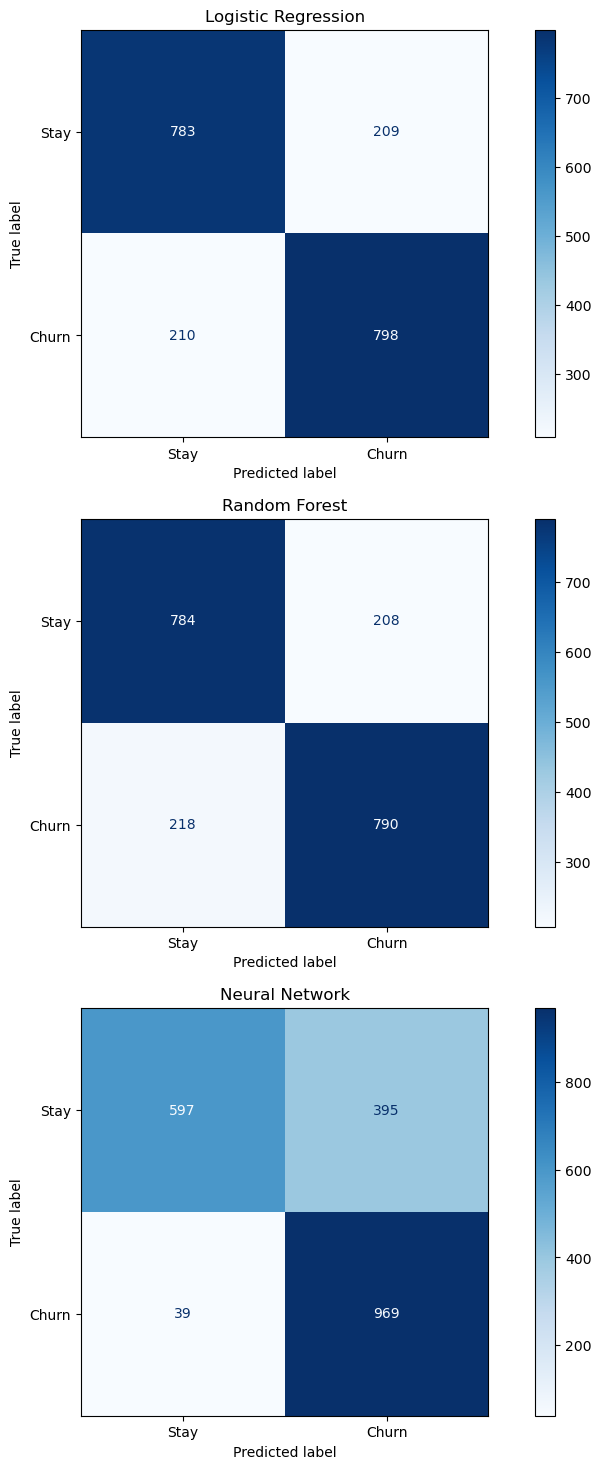

In [250]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_nn = confusion_matrix(y_test, predictions_nn)
cm_lr = confusion_matrix(y_test, predictions_lr)
cm_rf = confusion_matrix(y_test, predictions_rf)

disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['Stay', 'Churn'])
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Stay', 'Churn'])
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Stay', 'Churn'])

fig, axes = plt.subplots(3,1, figsize=(12,18))

disp_lr.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title("Logistic Regression")

disp_rf.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Random Forest")

disp_nn.plot(cmap=plt.cm.Blues, ax=axes[2])
axes[2].set_title("Neural Network")

plt.show()


## Conclusion & Business-Driven Model Selection

Ultimately, selecting the best model cannot be done using pure mathematics alone; it must be driven by the specific financial constraints and business objectives of TelcoConnect. We have isolated two champion models, each suited for a distinct business strategy:

### Scenario A: Retention is Cheap (High Recall Focus)
If the cost of missing a churner is significantly higher than the cost of a false alarm (e.g., the retention strategy is simply sending an automated discount email), the **Neural Network** is the undisputed winner.
* **Recall:** 0.96 (Catches almost every churner)
* **Precision:** 0.71 (Generates more false alarms)

### Scenario B: Retention is Expensive (Balanced Focus)
If the cost of a false alarm is high (e.g., assigning a human account manager or offering expensive hardware upgrades to retain the customer), we must prioritize precision to avoid wasting resources on customers who were never going to leave. Here, the **Logistic Regression** model shines.
* **Recall:** 0.79 
* **Precision:** 0.79 

### Final Decision
For the TelcoConnect deployment, we are selecting the **Logistic Regression** model. It provides a highly balanced, stable, and computationally lightweight solution that protects the company from expensive false positives while still successfully identifying the vast majority of at-risk customers. 